<!-- NINO26-CABECALHO v1 -->
# 3G — Compostos de SSTA por classe NOAA e comparação 2025/26

**Projeto NINO-BRASIL — Oceanografia Física UFPE — Thiago Vilar**  
**Código da fase/letra:** `3G`  ·  **Hipótese:** HIP0

## Descritivo (por que este notebook existe)
Compara a evolução espacial da SSTA por classe de intensidade e situa a formação 2025/26 frente aos eventos fortes — a leitura de epicentro e escalonamento do aquecimento.

## Pergunta
Como a SSTA evolui por classe NOAA e como 2025/26 se compara aos eventos fortes/muito fortes por longitude? Onde fica o epicentro?

## Desafio (hipótese a testar)
Distinguir intensidade de localização (canônico vs Modoki) exige comparar padrões espaciais, não só o índice escalar.

## Metodologia (com referências)
Compostos de SSTA alinhados por classe e por longitude, com estado atual sobreposto (diversidade de eventos — Timmermann et al., 2018; Trenberth, 1997).

## Contrato de saídas — código predecessor único
Cada figura nasce do **mesmo** `registrar_figura(...)` que congela sua numeric-table sob o **mesmo código**, reescrevendo por **sobreposição** a cada execução. A fonte deve ser uma tabela persistida com sidecar e hash do mesmo `run_id`:

```python
from nino_brasil.viz import registrar_figura
registrar_figura(fig, "Fig_3G01", fase=3, bloco="G",
                 titulo=..., descricao=..., hipotese="HIP0",
                 notebook="notebooks/fase3/3G_compostos_ssta.ipynb",
                 run_id=run.run_id,
                 fontes={"<tabela>": tabela_path})   # Path + .manifest.json -> figures/fase3/<codigo>.png + numeric-tables/fase3/<codigo>/
```

| Código | Figura (`figures/fase3/<código>.png`) | Numeric-table (`numeric-tables/fase3/<código>/`) | Descrição |
|---|---|---|---|
| `Fig_3G01` | `Fig_3G01.png` | `Fig_3G01/` | composto de SSTA por classe NOAA |
| `Fig_3G02` | `Fig_3G02.png` | `Fig_3G02/` | escalonamento de SSTA |
| `Fig_3G03` | `Fig_3G03.png` | `Fig_3G03/` | mapa de SSTA por longitude |

> Padrão em `docs/PADRAO_NOTEBOOKS.md`; compatibilidade por `python scripts/validar_figuras.py --strict --allow-render-extraction`; promoção por `python scripts/validar_figuras.py --strict`.

[tabela semântica] data\processed\parquet\statistics\phase3G_composto_ssta_classes_noaa.csv


[tabela semântica] data\processed\parquet\statistics\phase3G_composto_ssta.csv


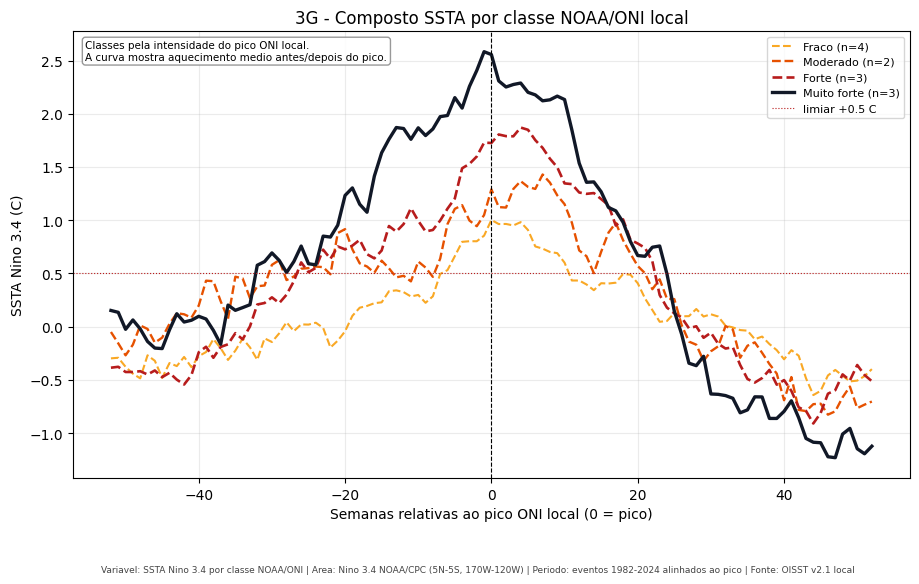

In [1]:
import sys; sys.path.insert(0,'.')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import fase3_utils as u

w = pd.read_csv(u.DERIVED_FEAT/'phase3_indices_semanais.csv', parse_dates=['week_ending_sunday']).set_index('week_ending_sunday')
ev = u.events_noaa()
ssta = w['nino34_ssta']
lags = list(range(-52, 53))
groups = u.elnino_mean_groups(ev)

def comp(series, events):
    mm = []
    for _, e in events.iterrows():
        i = series.index.get_indexer([e.peak_time], method='nearest')[0]
        seg = series.iloc[max(0, i-52):i+53]
        rel = ((seg.index - series.index[i]).days / 7).round().astype(int)
        mm.append(pd.Series(seg.values, index=rel).reindex(lags))
    return pd.DataFrame(mm).mean() if mm else pd.Series(index=lags, dtype=float)

records = []
comps = {}
for grupo, gg in groups.items():
    comps[grupo] = comp(ssta, gg)
    for lag, val in comps[grupo].items():
        records.append({'grupo': grupo, 'rotulo': u.elnino_group_label(grupo, short=True), 'n_eventos': len(gg), 'semana_rel_pico': int(lag), 'ssta_c': val})
cp_long = pd.DataFrame(records)
u.save_table(cp_long, 'phase3G_composto_ssta_classes_noaa.csv', index=False)
cp_all = comp(ssta, ev).rename('ssta_c').to_frame().rename_axis('semana_rel_pico')
u.save_table(cp_all, 'phase3G_composto_ssta.csv')

fig, ax = plt.subplots(figsize=(10.8, 5.8))
for grupo in u.ELNINO_MEAN_GROUP_ORDER:
    if len(groups[grupo]) == 0:
        continue
    meta = u.elnino_group_style(grupo)
    ax.plot(lags, comps[grupo].values, color=meta['color'], lw=meta['linewidth'], ls=meta['linestyle'], label=f"{meta['rotulo_curto']} (n={len(groups[grupo])})")
ax.axvline(0, color='k', lw=.8, ls='--')
ax.axhline(0.5, color='#b91c1c', lw=.8, ls=':', label='limiar +0.5 C')
ax.set_xlabel('Semanas relativas ao pico ONI local (0 = pico)')
ax.set_ylabel('SSTA Nino 3.4 (C)')
ax.set_title('3G - Composto SSTA por classe NOAA/ONI local')
ax.grid(alpha=.25)
ax.legend(fontsize=8)
u.add_note(ax, 'Classes pela intensidade do pico ONI local.\nA curva mostra aquecimento medio antes/depois do pico.', loc='upper left')
u.stamp_caption(fig, variavel='SSTA Nino 3.4 por classe NOAA/ONI', area=u.CAIXAS['nino34'], periodo='eventos 1982-2024 alinhados ao pico', fonte='OISST v2.1 local')
u.save_fig(fig, '3G1_composto_ssta_noaa.png', fontes={'composto_classes': 'phase3G_composto_ssta_classes_noaa.csv', 'composto_agregado': 'phase3G_composto_ssta.csv'})
plt.show()


[tabela semântica] data\processed\parquet\statistics\phase3G_eventos_ssta.csv


[tabela semântica] data\processed\parquet\statistics\phase3G_escalonamento_ssta.csv


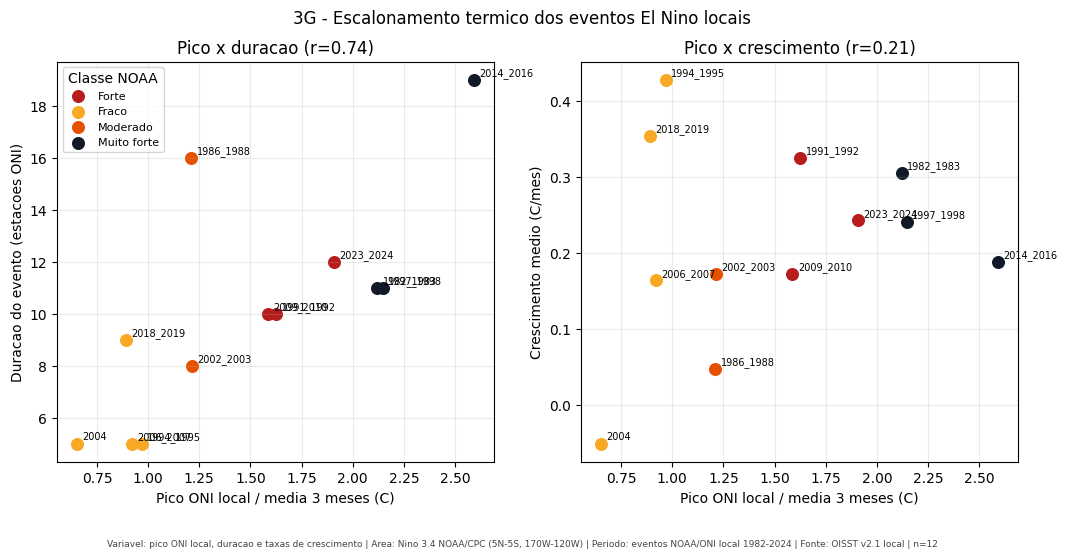

In [2]:
taxas = pd.read_csv(u.STATS / 'phase3B_eventos_taxas.csv')
met = taxas[['event_id','classe','oni_pico_c','ssta_mensal_pico_c','duracao_estacoes_oni','crescimento_c_por_mes','decaimento_c_por_mes']].copy()
u.save_table(met, 'phase3G_eventos_ssta.csv', index=False)
mm = met.dropna(subset=['oni_pico_c','duracao_estacoes_oni','crescimento_c_por_mes'])
ri = float(np.corrcoef(mm['oni_pico_c'], mm['duracao_estacoes_oni'])[0,1])
rg = float(np.corrcoef(mm['oni_pico_c'], mm['crescimento_c_por_mes'])[0,1])
stat = pd.DataFrame([
    {'relacao':'oni_pico x duracao_oni','r':round(ri,3),'n':len(mm)},
    {'relacao':'oni_pico x crescimento','r':round(rg,3),'n':len(mm)},
])
u.save_table(stat, 'phase3G_escalonamento_ssta.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(12.4, 5.2))
for cls, g in mm.groupby('classe'):
    meta = u.elnino_group_style(cls)
    axes[0].scatter(g['oni_pico_c'], g['duracao_estacoes_oni'], label=meta['rotulo_curto'], color=meta['color'], s=70)
    axes[1].scatter(g['oni_pico_c'], g['crescimento_c_por_mes'], label=meta['rotulo_curto'], color=meta['color'], s=70)
    for _, r in g.iterrows():
        lab = str(r['event_id']).replace('el_nino_oisst_','')
        axes[0].annotate(lab, (r['oni_pico_c'], r['duracao_estacoes_oni']), fontsize=7, xytext=(4,3), textcoords='offset points')
        axes[1].annotate(lab, (r['oni_pico_c'], r['crescimento_c_por_mes']), fontsize=7, xytext=(4,3), textcoords='offset points')
axes[0].set_xlabel('Pico ONI local / media 3 meses (C)')
axes[0].set_ylabel('Duracao do evento (estacoes ONI)')
axes[0].set_title(f'Pico x duracao (r={ri:.2f})')
axes[1].set_xlabel('Pico ONI local / media 3 meses (C)')
axes[1].set_ylabel('Crescimento medio (C/mes)')
axes[1].set_title(f'Pico x crescimento (r={rg:.2f})')
for ax in axes:
    ax.grid(alpha=.25)
axes[0].legend(fontsize=8, title='Classe NOAA')
fig.suptitle('3G - Escalonamento termico dos eventos El Nino locais')
u.stamp_caption(fig, variavel='pico ONI local, duracao e taxas de crescimento', area=u.CAIXAS['nino34'], periodo='eventos NOAA/ONI local 1982-2024', fonte='OISST v2.1 local', n=str(len(mm)))
u.save_fig(fig, '3G2_escalonamento_ssta.png', fontes={'eventos': 'phase3G_eventos_ssta.csv', 'escalonamento': 'phase3G_escalonamento_ssta.csv'})
plt.show()


[tabela semântica] data\processed\parquet\statistics\phase3G_mapa_ssta_lon_eventos_forte_super.csv


[tabela semântica] data\processed\parquet\statistics\phase3G_estado_atual.csv


                       painel      classe      referencia_t0  ssta_lon_max_c  semana_relativa_max mes_ano_epicentro longitude_max
        1982/83 | Muito forte muito_forte 0 = pico ONI local            5.44                  0.1           01/1983          127W
              1991/92 | Forte       forte 0 = pico ONI local            3.68                 16.6           04/1992           86W
        1997/98 | Muito forte muito_forte 0 = pico ONI local            5.39                 -0.1           11/1997          106W
              2009/10 | Forte       forte 0 = pico ONI local            3.18                  4.7           01/2010          162W
        2014/16 | Muito forte muito_forte 0 = pico ONI local            4.19                 -1.3           11/2015          123W
              2023/24 | Forte       forte 0 = pico ONI local            4.46                -13.7           08/2023           97W
2025/26 atual | t0=2026-06-14       atual    0 = ultimo dado            3.52              

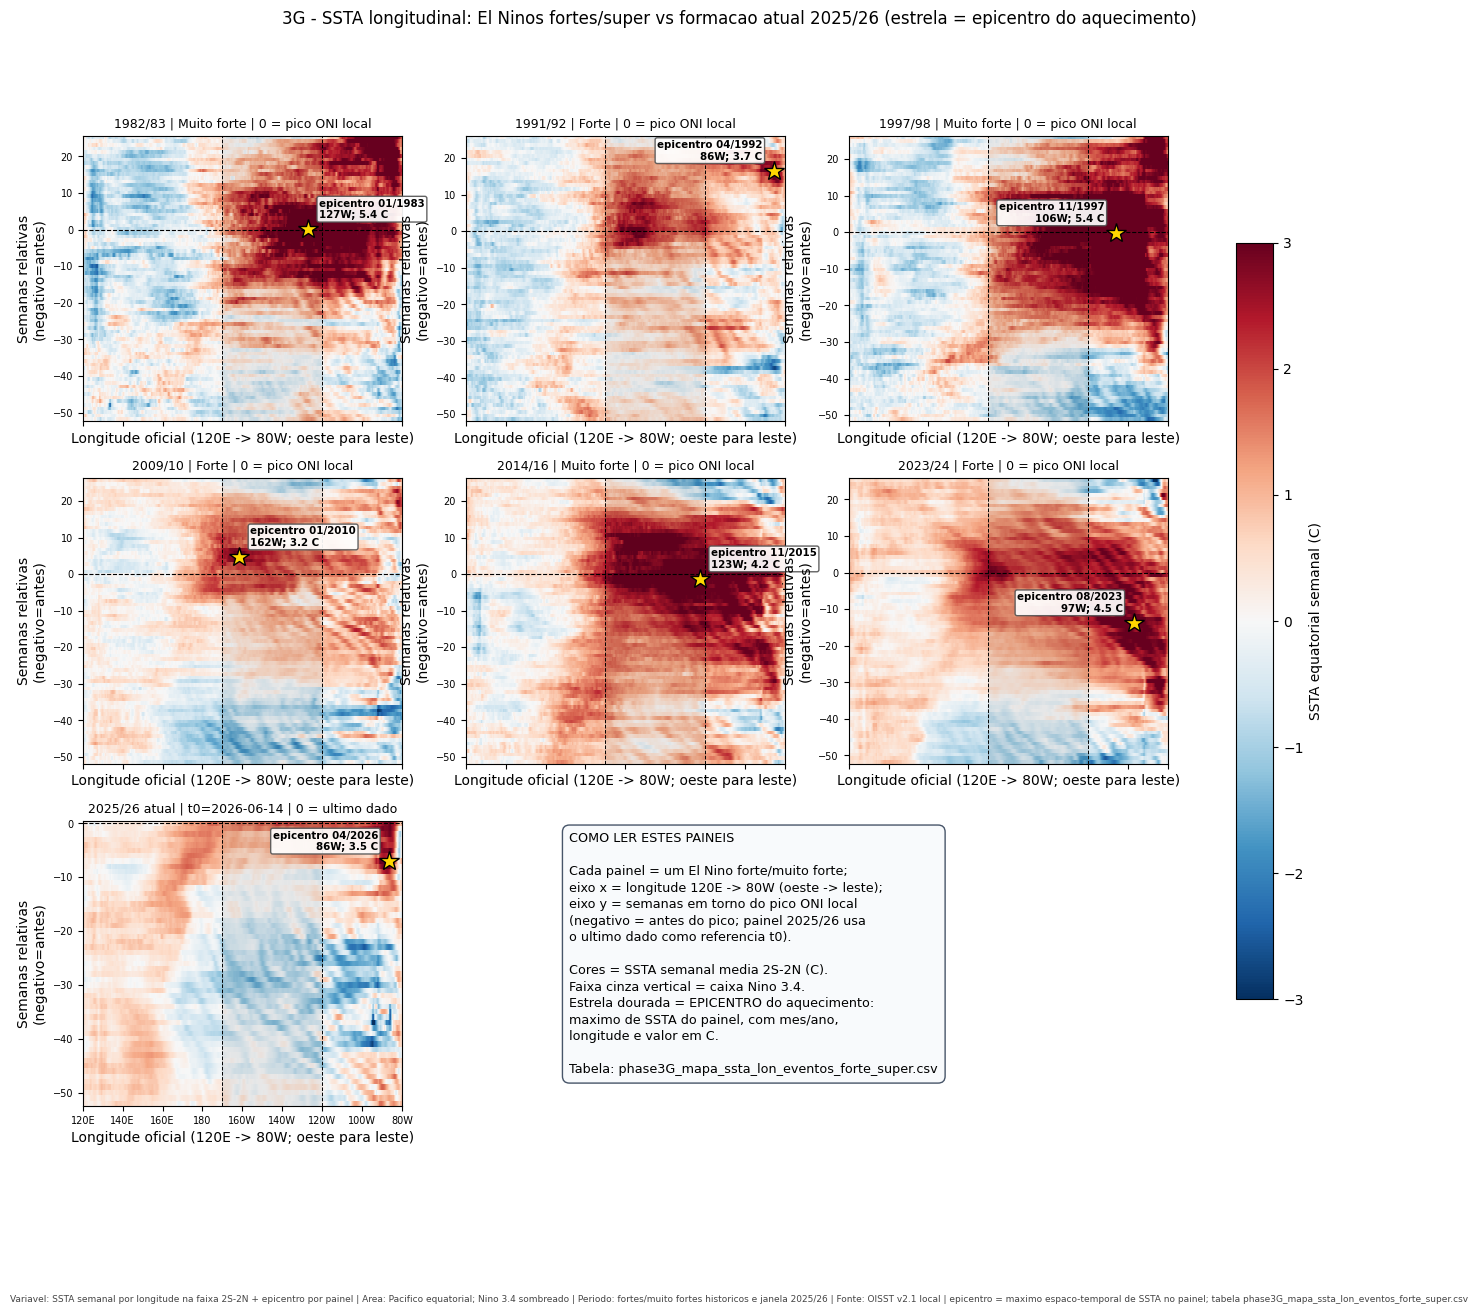

In [3]:
eq = u.load_eqband_weekly()
ev = u.events_noaa()
strong = ev[ev['classe_noaa'].isin(['forte', 'muito_forte'])].sort_values('peak_time')
latest = min(eq.dropna(how='all').index.max(), pd.Timestamp('2026-12-31'))
panels = []
for _, e in strong.iterrows():
    start = e.peak_time - pd.Timedelta(weeks=52)
    end = e.peak_time + pd.Timedelta(weeks=26)
    seg = eq.loc[start:end]
    if seg.empty:
        continue
    rel = ((seg.index - e.peak_time).days / 7).astype(float)
    label = f"{e.event_start.year}/{str(e.event_end.year)[-2:]} | {u.elnino_group_label(e.classe_noaa, short=True)}"
    panels.append((label, seg, rel, '0 = pico ONI local', e.classe_noaa, e.peak_time))
seg_now = eq.loc[latest - pd.Timedelta(weeks=52):latest]
rel_now = ((seg_now.index - latest).days / 7).astype(float)
panels.append((f'2025/26 atual | t0={latest.date()}', seg_now, rel_now, '0 = ultimo dado', 'atual', latest))

n = len(panels)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(17.5, 4.2*nrows), sharex=True, sharey=False)
axes = np.atleast_1d(axes).ravel()
lon = eq.columns.values.astype(float)
rows = []
last_pc = None
for ax, (label, seg, rel, ref, cls, t0) in zip(axes, panels):
    last_pc = ax.pcolormesh(lon, rel, seg.values, cmap='RdBu_r', vmin=-3, vmax=3, shading='auto')
    u.add_nino34_lon_band(ax, label=False)
    u.format_lon_axis(ax)
    ax.axhline(0, color='k', lw=.8, ls='--')
    ax.set_ylabel('Semanas relativas\n(negativo=antes)')
    ax.set_title(label + ' | ' + ref, fontsize=9)
    ax.tick_params(labelsize=7)
    finite = np.isfinite(seg.values)
    if finite.any():
        mx = float(np.nanmax(seg.values))
        rr, cc = np.unravel_index(np.nanargmax(seg.values), seg.values.shape)
        lon_ep, sem_ep = float(lon[cc]), float(rel[rr])
        mesano = seg.index[rr].strftime('%m/%Y')
        rows.append({'painel': label, 'classe': cls, 'referencia_t0': ref, 'ssta_lon_max_c': round(mx, 2),
                     'semana_relativa_max': round(sem_ep, 1), 'mes_ano_epicentro': mesano,
                     'longitude_max': u.lon_label(lon_ep)})
        # EPICENTRO: estrela + rotulo mes/ano e longitude
        ax.plot(lon_ep, sem_ep, marker='*', ms=15, mfc='#ffd700', mec='k', mew=1.0, zorder=6)
        dx = -8 if lon_ep > 240 else 8
        ax.annotate(f'epicentro {mesano}\n{u.lon_label(lon_ep)}; {mx:.1f} C', xy=(lon_ep, sem_ep),
                    xytext=(dx, 8), textcoords='offset points', fontsize=7.4, weight='bold',
                    ha='right' if lon_ep > 240 else 'left',
                    bbox={'boxstyle': 'round,pad=0.2', 'facecolor': 'white', 'edgecolor': '#555', 'alpha': .92}, zorder=6)
for ax in axes[n:]:
    ax.axis('off')
# LEGENDA INTERNA no espaco vazio da grade
ax_leg = axes[n] if n < len(axes) else None
if ax_leg is not None:
    ax_leg.text(0.02, 0.96,
        'COMO LER ESTES PAINEIS\n\n'
        'Cada painel = um El Nino forte/muito forte;\n'
        'eixo x = longitude 120E -> 80W (oeste -> leste);\n'
        'eixo y = semanas em torno do pico ONI local\n'
        '(negativo = antes do pico; painel 2025/26 usa\n'
        'o ultimo dado como referencia t0).\n\n'
        'Cores = SSTA semanal media 2S-2N (C).\n'
        'Faixa cinza vertical = caixa Nino 3.4.\n'
        'Estrela dourada = EPICENTRO do aquecimento:\n'
        'maximo de SSTA do painel, com mes/ano,\n'
        'longitude e valor em C.\n\n'
        'Tabela: phase3G_mapa_ssta_lon_eventos_forte_super.csv',
        transform=ax_leg.transAxes, fontsize=9.2, va='top', ha='left', linespacing=1.35,
        bbox={'boxstyle': 'round,pad=0.55', 'facecolor': '#f8fafc', 'edgecolor': '#475569'})
fig.suptitle('3G - SSTA longitudinal: El Ninos fortes/super vs formacao atual 2025/26 (estrela = epicentro do aquecimento)')
if last_pc is not None:
    fig.colorbar(last_pc, ax=axes[:n], label='SSTA equatorial semanal (C)', shrink=.78)
u.stamp_caption(fig, variavel='SSTA semanal por longitude na faixa 2S-2N + epicentro por painel', area='Pacifico equatorial; Nino 3.4 sombreado', periodo='fortes/muito fortes historicos e janela 2025/26', fonte='OISST v2.1 local', extra='epicentro = maximo espaco-temporal de SSTA no painel; tabela phase3G_mapa_ssta_lon_eventos_forte_super.csv')
maptab = pd.DataFrame(rows)
u.save_table(maptab, 'phase3G_mapa_ssta_lon_eventos_forte_super.csv', index=False)
at = float(np.nanmax(seg_now.values)) if np.isfinite(seg_now.values).any() else np.nan
u.save_table(pd.DataFrame([{'ssta_lon_max_atual_c': round(at, 2), 'data_referencia': str(latest.date())}]), 'phase3G_estado_atual.csv', index=False)
u.save_fig(fig, '3G3_mapa_ssta_lon.png', fontes={'mapa_eventos': 'phase3G_mapa_ssta_lon_eventos_forte_super.csv', 'estado_atual': 'phase3G_estado_atual.csv'})
print(maptab.to_string(index=False))
plt.show()


**Leitura do 3G.** A etapa 3G compara apenas o alvo termico oficial da Fase 3: SSTA/ONI local. Eventos mais intensos tendem a combinar pico maior, duracao maior e crescimento mais rapido. O mapa longitudinal 3G3 agora marca o EPICENTRO do aquecimento de cada painel (estrela dourada: mes/ano, longitude e valor em C) e traz legenda interna de leitura; o painel 2025/26 e alinhado ao ultimo dado porque o pico futuro ainda nao e conhecido - seu epicentro ate agora (86W) e mais costeiro que o dos eventos fortes historicos, sinal de configuracao tipo leste na formacao atual.


<!-- NINO26-REFERENCIAS v1 -->
## Referências Bibliográficas

1. Timmermann, A., et al. (2018). El Niño-Southern Oscillation complexity. *Nature*, 559, 535-545. https://doi.org/10.1038/s41586-018-0252-6
2. Trenberth, K. E. (1997). The Definition of El Niño. *BAMS*, 78, 2771-2777. https://doi.org/10.1175/1520-0477(1997)078<2771:TDOENO>2.0.CO;2

Relação completa em `Artigos_Referências/Referências_Bibliográficas.xls`.